In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random_s = 101

In [226]:
df = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster_mpg.csv")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
388,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
389,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
390,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [227]:
df = df.drop(['name'], axis=1)
df.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


In [228]:
df['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [229]:
df_origin_dummies = pd.get_dummies(df['origin'], prefix='origin').astype('float')
df_origin_dummies.head()


,origin_europe,origin_japan,origin_usa
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [230]:
df_cleaned = pd.concat([df.drop('origin', axis=1), df_origin_dummies], axis=1)
df_cleaned.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0.0,0.0,1.0
1,15.0,8,350.0,165.0,3693,11.5,70,0.0,0.0,1.0
2,18.0,8,318.0,150.0,3436,11.0,70,0.0,0.0,1.0
3,16.0,8,304.0,150.0,3433,12.0,70,0.0,0.0,1.0
4,17.0,8,302.0,140.0,3449,10.5,70,0.0,0.0,1.0


In [231]:
df_cleaned.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin_europe,0
origin_japan,0
origin_usa,0


SCALED DATA

In [232]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)
df_scaled

array([[-0.69863841,  1.48394702,  1.07728956, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [-1.08349824,  1.48394702,  1.48873169, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [-0.69863841,  1.48394702,  1.1825422 , ..., -0.45812285,
        -0.50239045,  0.77459667],
       ...,
       [ 1.09737414, -0.86401356, -0.56847897, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [ 0.5842277 , -0.86401356, -0.7120053 , ..., -0.45812285,
        -0.50239045,  0.77459667],
       [ 0.96908753, -0.86401356, -0.72157372, ..., -0.45812285,
        -0.50239045,  0.77459667]])

In [233]:
df_scaled = pd.DataFrame(df_scaled, columns = df_cleaned.columns)
df_scaled.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,-0.698638,1.483947,1.077290,0.664133,0.620540,-1.285258,-1.625315,-0.458123,-0.50239,0.774597
1,-1.083498,1.483947,1.488732,1.574594,0.843334,-1.466724,-1.625315,-0.458123,-0.50239,0.774597
2,-0.698638,1.483947,1.182542,1.184397,0.540382,-1.648189,-1.625315,-0.458123,-0.50239,0.774597


In [234]:
# Perform Principal Component Analysis (PCA)
from sklearn.decomposition import PCA

pca = PCA()
df_pca = pca.fit_transform(df_scaled)

In [235]:
#2. What is the scaled value of data or index 85 after scaling in terms of displacement? Write the answer on your paper.
scaled_displacement_85 = df_scaled.loc[85, 'displacement']
print(f"The scaled displacement value at index 85 is: {scaled_displacement_85}")

The scaled displacement value at index 85 is: 1.048584292818992


In [236]:
correlation_matrix = df_cleaned.corr()

correlation_matrix

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.244313,0.451454,-0.565161
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.352324,-0.404209,0.610494
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.371633,-0.440825,0.655936
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.284948,-0.321936,0.489625
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.293841,-0.447929,0.600978
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.208298,0.115020,-0.258224
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,-0.037745,0.199841,-0.136065
origin_europe,0.244313,-0.352324,-0.371633,-0.284948,-0.293841,0.208298,-0.037745,1.000000,-0.230157,-0.591434
origin_japan,0.451454,-0.404209,-0.440825,-0.321936,-0.447929,0.115020,0.199841,-0.230157,1.000000,-0.648583
origin_usa,-0.565161,0.610494,0.655936,0.489625,0.600978,-0.258224,-0.136065,-0.591434,-0.648583,1.000000


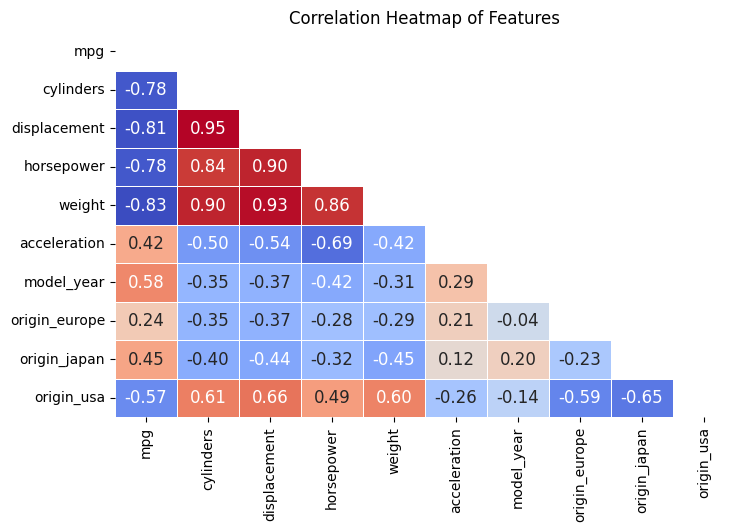

In [237]:
plt.figure(figsize = (8,5))

mask = np.triu(np.ones_like(correlation_matrix, dtype = bool))

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm',
            linewidths = 0.5, fmt = '.2f', annot_kws={"size": 12}, cbar = False, mask = mask)
plt.title("Correlation Heatmap of Features")
plt.show()

In [238]:
correlation_matrix[correlation_matrix < 1].unstack().drop_duplicates().sort_values(ascending = False)

,,0
cylinders,displacement,0.950823
displacement,weight,0.932994
cylinders,weight,0.897527
displacement,horsepower,0.897257
horsepower,weight,0.864538
cylinders,horsepower,0.842983
displacement,origin_usa,0.655936
cylinders,origin_usa,0.610494
weight,origin_usa,0.600978
mpg,model_year,0.580541


In [239]:
# 3. What is the explained variance of PC0?
explained_variance_pc0 = pca.explained_variance_ratio_[0]
print(f"The explained variance of PC0 is: {explained_variance_pc0: }")

The explained variance of PC0 is:  0.5788575314058662


In [240]:
# 4. What is the total explained variance of PC0 and PC1?
total_explained_variance_pc0_pc1 = pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]
print(f"The total explained variance of PC0 and PC1 is: {total_explained_variance_pc0_pc1: }")

The total explained variance of PC0 and PC1 is:  0.7118300241528728


In [241]:
# 5. What is the total explained variance of PC0, PC1 and PC2?
total_explained_variance_pc0_pc1_pc2 = pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1] + pca.explained_variance_ratio_[2]
print(f"The total explained variance of PC0, PC1 and PC2 is: {total_explained_variance_pc0_pc1_pc2: }")

The total explained variance of PC0, PC1 and PC2 is:  0.8303350791192141


In [242]:
# 6. Using only two principal components, what is the value of PC0 and PC1 at index 285?
pc0_at_index_285 = df_pca[285, 0]
pc1_at_index_285 = df_pca[285, 1]

print(f"The value of PC0 at index 285 is: {pc0_at_index_285: }")
print(f"The value of PC1 at index 285 is: {pc1_at_index_285: }")

The value of PC0 at index 285 is:  2.7456413189807485
The value of PC1 at index 285 is: -0.6541014878447338


In [243]:
# 7. Using three principal components, what is the value of PC0, PC1, and PC2 at index 300?

pc0_at_index_300 = df_pca[300, 0]
pc1_at_index_300 = df_pca[300, 1]
pc2_at_index_300 = df_pca[300, 2]

print(f"The value of PC0 at index 300 is: {pc0_at_index_300: }")
print(f"The value of PC1 at index 300 is: {pc1_at_index_300: }")
print(f"The value of PC2 at index 300 is: {pc2_at_index_300: }")

The value of PC0 at index 300 is: -1.6016079686808165
The value of PC1 at index 300 is: -0.8263315855241968
The value of PC2 at index 300 is: -1.1454320362883155


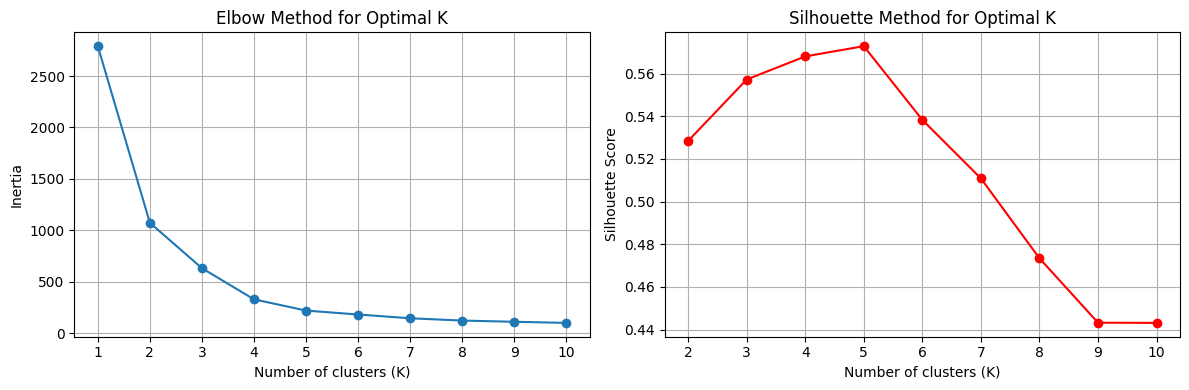

In [244]:
# 8. Perform a KMeans Clustering, find optimal K based on PC0 and PC1
# Using elbow method and silhouette score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

pca_components = df_pca[:, :2]

# Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=random_s, n_init=10)
    kmeans.fit(pca_components)
    inertia.append(kmeans.inertia_)

# Silhouette Method
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=random_s, n_init=10)
    kmeans.fit(pca_components)
    score = silhouette_score(pca_components, kmeans.labels_)
    silhouette_scores.append(score)

# Create subplots for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot Elbow Method
axes[0].plot(range(1, 11), inertia, marker='o')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].set_xticks(range(1, 11))
axes[0].grid(True)

# Plot Silhouette Method
axes[1].plot(range(2, 11), silhouette_scores, marker='o', color='red')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Method for Optimal K')
axes[1].set_xticks(range(2, 11))
axes[1].grid(True)

plt.tight_layout()
plt.show()

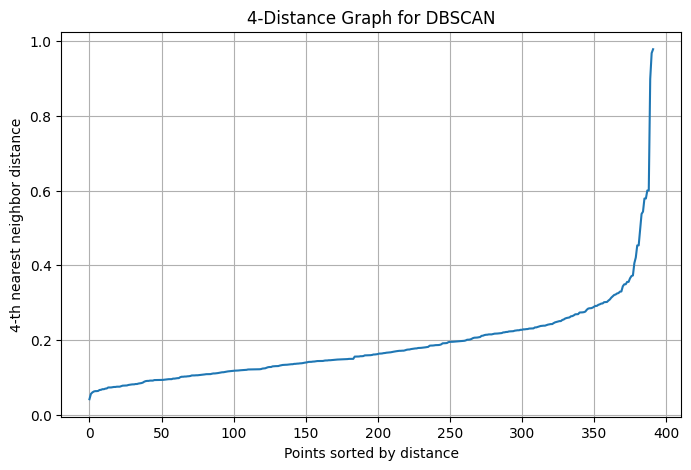

In [246]:
# 9. Perform a DBSCAN Clustering.
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

pca_components = df_pca[:, :2]

k = 4

neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(pca_components)
distances, indices = neigh.kneighbors(pca_components)

distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-th nearest neighbor distance')
plt.title(f'{k}-Distance Graph for DBSCAN')
plt.grid(True)
plt.show()

In [247]:
# 10. What are you recommending as the min_samples value based strictly on best practice?

#min_samples ≈ 2 × number_of_dimensions
recommended_min_samples = 2 * 2
print(f"recommended min_samples value is: {recommended_min_samples}")

recommended min_samples value is: 4


In [248]:
# 11. How many outliers can the DBSCAN detect based on the optimal epsilon score and the recommended min_samples?

from sklearn.cluster import DBSCAN

pca_components = df_pca[:, :2]

db = DBSCAN(eps=0.5, min_samples=4)
labels = db.fit_predict(pca_components)

outliers = list(labels).count(-1)

print(f"number of outliers detected by DBSCAN : {outliers}")

number of outliers detected by DBSCAN : 6


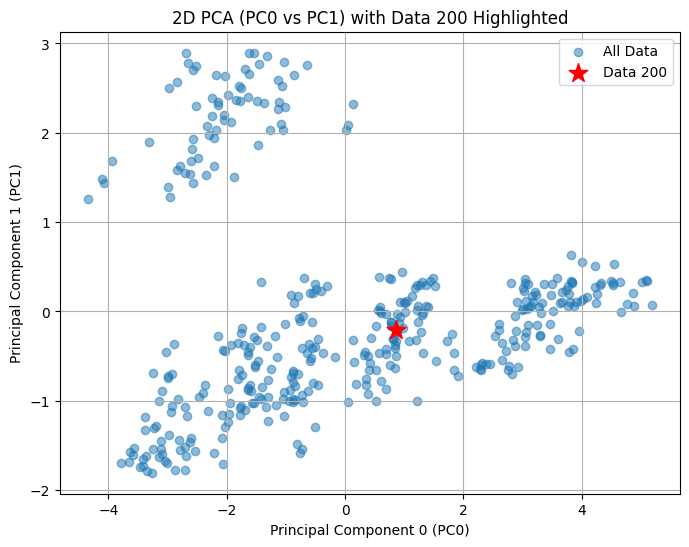

In [249]:
# a. 2D scatter plot of PC0 vs PC1, highlighting Data 200

plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], alpha=0.5, label='All Data')
plt.scatter(df_pca[200, 0], df_pca[200, 1], marker='*', s=200, color='red', label='Data 200')
plt.xlabel('Principal Component 0 (PC0)')
plt.ylabel('Principal Component 1 (PC1)')
plt.title('2D PCA (PC0 vs PC1) with Data 200 Highlighted')
plt.legend()
plt.grid(True)
plt.show()


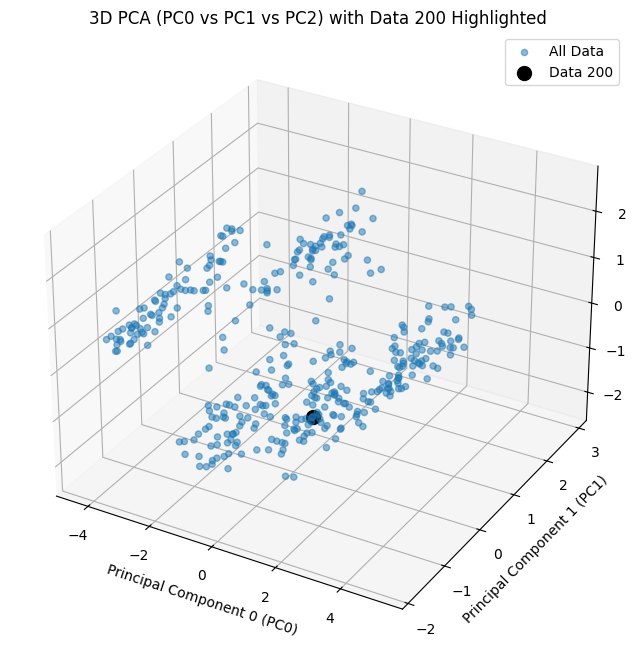

In [250]:
# b. 3D scatter plot of PC0, PC1, and PC2, highlighting Data 200

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_pca[:, 0], df_pca[:, 1], df_pca[:, 2], alpha=0.5, label='All Data')
ax.scatter(df_pca[200, 0], df_pca[200, 1], df_pca[200, 2], marker='o', s=100, color='black', label='Data 200')

ax.set_xlabel('Principal Component 0 (PC0)')
ax.set_ylabel('Principal Component 1 (PC1)')
ax.set_zlabel('Principal Component 2 (PC2)')
ax.set_title('3D PCA (PC0 vs PC1 vs PC2) with Data 200 Highlighted')
ax.legend()

plt.show()